# Shooting Accuracy Analysis

## Research Question

Is there a statistically significant difference in average shooting accuracy between forwards and midfielders in the FIFA World Cup 2026?

## Hypotheses

H0: μFW = μMF

Ha: μFW ≠ μMF

Significance level: α = 0.05

Statistical test: Welch independent two-sample t-test.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

RANDOM_STATE = 42
ALPHA = 0.05

In [65]:
DATA_PATH = Path("data/fifa2026_shooting.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (1039, 19)


,Rk,Player,Pos,Squad,Age,Born,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,3,1,33.3,3.55,1.18,0.0,0.0,0,0,Matches,5bc43860
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,1,2,1,50.0,2.00,1.00,0.5,1.0,0,0,Matches,c88a28b9
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,057d8f12
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,accbfc94
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,bff15d74


In [66]:
print(df.columns.tolist())

['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'Gls', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK', 'PKatt', 'Matches', '-9999']


In [67]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['rk', 'player', 'pos', 'squad', 'age', 'born', '90s', 'gls', 'sh', 'sot', 'sot%', 'sh/90', 'sot/90', 'g/sh', 'g/sot', 'pk', 'pkatt', 'matches', '-9999']


In [68]:
analysis_df = df[
    [
        "player",
        "squad",
        "pos",
        "90s",
        "sh",
        "sot"
    ]
].copy()

display(analysis_df.head())

,player,squad,pos,90s,sh,sot
0,Brenden Aaronson,us USA,MF,0.8,3,1
1,Thelo Aasgaard,no Norway,MF,1.0,2,1
2,Hamza Abdelkarim,eg Egypt,FW,0.7,0,0
3,Hossam Abdelmaguid,eg Egypt,DF,0.7,0,0
4,Mohamed Abdelmonem,eg Egypt,DF,0.2,0,0


In [69]:
numeric_columns = [
    "90s",
    "sh",
    "sot"
]

for column in numeric_columns:
    analysis_df[column] = pd.to_numeric(
        analysis_df[column],
        errors="coerce"
    )

In [70]:
analysis_df = analysis_df.dropna(
    subset=[
        "player",
        "squad",
        "pos",
        "90s",
        "sh",
        "sot"
    ]
).copy()

print(
    "Rows after removing missing data:",
    len(analysis_df)
)

Rows after removing missing data: 1039


In [71]:
analysis_df = (
    analysis_df
    .drop_duplicates()
    .copy()
)

print(
    "Rows after duplicate removal:",
    len(analysis_df)
)

Rows after duplicate removal: 1039


In [72]:
analysis_df = analysis_df[
    analysis_df["90s"] >= 1.0
].copy()

print(
    "Players with at least 90 minutes:",
    len(analysis_df)
)

Players with at least 90 minutes: 743


In [73]:
analysis_df = analysis_df[
    analysis_df["sh"] > 0
].copy()

print(
    "Players with at least one shot:",
    len(analysis_df)
)

Players with at least one shot: 559


In [74]:
analysis_df["shooting_accuracy"] = (
    analysis_df["sot"]
    /
    analysis_df["sh"]
) * 100

In [75]:
display(
    analysis_df[
        [
            "player",
            "squad",
            "pos",
            "sh",
            "sot",
            "shooting_accuracy"
        ]
    ].head(15)
)

,player,squad,pos,sh,sot,shooting_accuracy
1,Thelo Aasgaard,no Norway,MF,2,1,50.000000
5,Ali Abdi,tn Tunisia,DF,1,0,0.000000
6,Saud Abdulhamid,sa Saudi Arabia,DF,2,0,0.000000
11,Mohannad Abu Taha,jo Jordan,DF,1,0,0.000000
16,Ché Adams,sct Scotland,FW,1,1,100.000000
19,Ricardo Adé,ht Haiti,DF,4,1,25.000000
22,Jonas Adjetey,gh Ghana,DF,2,1,50.000000
23,Michel Aebischer,ch Switzerland,MFFW,2,1,50.000000
24,Akram Afif,qa Qatar,FWMF,2,0,0.000000
25,Emmanuel Agbadou,ci Côte d'Ivoire,DF,3,1,33.333333


In [76]:
print(
    analysis_df["pos"]
    .value_counts()
)

pos
MF      226
DF      171
FW       96
MFFW     34
FWMF     16
MFDF      8
DFMF      8
Name: count, dtype: int64


In [77]:
analysis_df["primary_position"] = (
    analysis_df["pos"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

print(
    analysis_df["primary_position"]
    .value_counts()
)

primary_position
MF      226
DF      171
FW       96
MFFW     34
FWMF     16
MFDF      8
DFMF      8
Name: count, dtype: int64


In [78]:
forwards = analysis_df[
    analysis_df["primary_position"] == "FW"
].copy()

print(
    "Eligible forwards:",
    len(forwards)
)

Eligible forwards: 96


In [79]:
midfielders = analysis_df[
    analysis_df["primary_position"] == "MF"
].copy()

print(
    "Eligible midfielders:",
    len(midfielders)
)

Eligible midfielders: 226


In [80]:
sample_size = min(
    30,
    len(forwards),
    len(midfielders)
)

forward_sample = forwards.sample(
    n=sample_size,
    random_state=RANDOM_STATE
)

midfielder_sample = midfielders.sample(
    n=sample_size,
    random_state=RANDOM_STATE
)

In [81]:
forward_sample = forwards.sample(
    n=80,
    random_state=42
)

midfielder_sample = midfielders.sample(
    n=80,
    random_state=42
)

print("Forwards sampled:", len(forward_sample))
print("Midfielders sampled:", len(midfielder_sample))

Forwards sampled: 80
Midfielders sampled: 80


In [82]:
print("FORWARD SAMPLE")

display(
    forward_sample[
        [
            "player",
            "squad",
            "sh",
            "sot",
            "shooting_accuracy"
        ]
    ]
)

print("MIDFIELDER SAMPLE")

display(
    midfielder_sample[
        [
            "player",
            "squad",
            "sh",
            "sot",
            "shooting_accuracy"
        ]
    ]
)

FORWARD SAMPLE


,player,squad,sh,sot,shooting_accuracy
896,Luis Suárez,co Colombia,9,0,0.000000
867,Eldor Shomurodov,uz Uzbekistan,4,2,50.000000
837,Patrik Schick,cz Czechia,2,1,50.000000
1005,Yoane Wissa,cd Congo DR,11,3,27.272727
415,Adam Hložek,cz Czechia,3,1,33.333333
...,...,...,...,...,...
962,Enner Valencia,ec Ecuador,10,6,60.000000
675,Darwin Núñez,uy Uruguay,2,0,0.000000
723,Nicolas Pépé,ci Côte d'Ivoire,6,3,50.000000
901,Pavel Šulc,cz Czechia,2,0,0.000000


MIDFIELDER SAMPLE


,player,squad,sh,sot,shooting_accuracy
87,Marwan Attia,eg Egypt,4,0,0.0
840,Xaver Schlager,at Austria,1,0,0.0
587,Thalente Mbatha,za South Africa,4,1,25.0
964,Federico Valverde,uy Uruguay,10,2,20.0
690,Michael Olise,fr France,20,5,25.0
...,...,...,...,...,...
1027,Jaroslav Zelený,cz Czechia,1,0,0.0
168,Moisés Caicedo,ec Ecuador,4,1,25.0
96,Juninho Bacuna,cw Curaçao,5,1,20.0
178,Josué Casimir,ht Haiti,1,0,0.0


In [83]:
forward_accuracy = (
    forward_sample[
        "shooting_accuracy"
    ]
)

midfielder_accuracy = (
    midfielder_sample[
        "shooting_accuracy"
    ]
)

In [84]:
def descriptive_statistics(series):
    series = pd.Series(series).dropna()

    return pd.Series({
        "n": len(series),
        "Mean": series.mean(),
        "Median": series.median(),
        "SD": series.std(ddof=1),
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "Min": series.min(),
        "Max": series.max()
    })

In [85]:
descriptive_table = pd.DataFrame({
    "Forwards":
        descriptive_statistics(
            forward_accuracy
        ),

    "Midfielders":
        descriptive_statistics(
            midfielder_accuracy
        )
})

display(
    descriptive_table.round(2)
)

,Forwards,Midfielders
n,80.00,80.00
Mean,38.62,29.80
Median,44.44,25.00
SD,28.82,29.34
Q1,0.00,0.00
Q3,52.17,50.00
Min,0.00,0.00
Max,100.00,100.00


In [86]:
def mean_confidence_interval(
    series,
    confidence=0.95
):
    series = pd.Series(series).dropna()

    n = len(series)
    mean = series.mean()
    standard_error = stats.sem(series)

    lower, upper = stats.t.interval(
        confidence,
        df=n - 1,
        loc=mean,
        scale=standard_error
    )

    return mean, lower, upper

In [87]:
fw_mean, fw_low, fw_high = (
    mean_confidence_interval(
        forward_accuracy
    )
)

mf_mean, mf_low, mf_high = (
    mean_confidence_interval(
        midfielder_accuracy
    )
)

print(
    f"Forward mean accuracy = "
    f"{fw_mean:.2f}%"
)

print(
    f"Forward 95% CI = "
    f"{fw_low:.2f}% to "
    f"{fw_high:.2f}%"
)

print()

print(
    f"Midfielder mean accuracy = "
    f"{mf_mean:.2f}%"
)

print(
    f"Midfielder 95% CI = "
    f"{mf_low:.2f}% to "
    f"{mf_high:.2f}%"
)

Forward mean accuracy = 38.62%
Forward 95% CI = 32.20% to 45.03%

Midfielder mean accuracy = 29.80%
Midfielder 95% CI = 23.27% to 36.33%


In [88]:
fw_shapiro = stats.shapiro(
    forward_accuracy
)

mf_shapiro = stats.shapiro(
    midfielder_accuracy
)

print(
    "Forwards Shapiro-Wilk:",
    fw_shapiro
)

print(
    "Midfielders Shapiro-Wilk:",
    mf_shapiro
)

Forwards Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9074524214021031), pvalue=np.float64(2.5500769780063297e-05))
Midfielders Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.8698942685858616), pvalue=np.float64(8.039706480191508e-07))


In [89]:
print("Forwards Shapiro-Wilk")
print("Statistic:", round(fw_shapiro.statistic, 4))
print("p-value:", f"{fw_shapiro.pvalue:.6f}")

print("\nMidfielders Shapiro-Wilk")
print("Statistic:", round(mf_shapiro.statistic, 4))
print("p-value:", f"{mf_shapiro.pvalue:.6f}")

Forwards Shapiro-Wilk
Statistic: 0.9075
p-value: 0.000026

Midfielders Shapiro-Wilk
Statistic: 0.8699
p-value: 0.000001


In [90]:
t_stat, p_value = stats.ttest_ind(
    forward_accuracy,
    midfielder_accuracy,
    equal_var=False
)

print(
    f"Welch t-statistic = "
    f"{t_stat:.4f}"
)

print(
    f"p-value = "
    f"{p_value:.4f}"
)

print(
    f"alpha = {ALPHA}"
)

Welch t-statistic = 1.9179
p-value = 0.0569
alpha = 0.05


In [91]:
if p_value < ALPHA:
    print(
        "Decision: Reject H0"
    )
else:
    print(
        "Decision: Do not reject H0"
    )

Decision: Do not reject H0


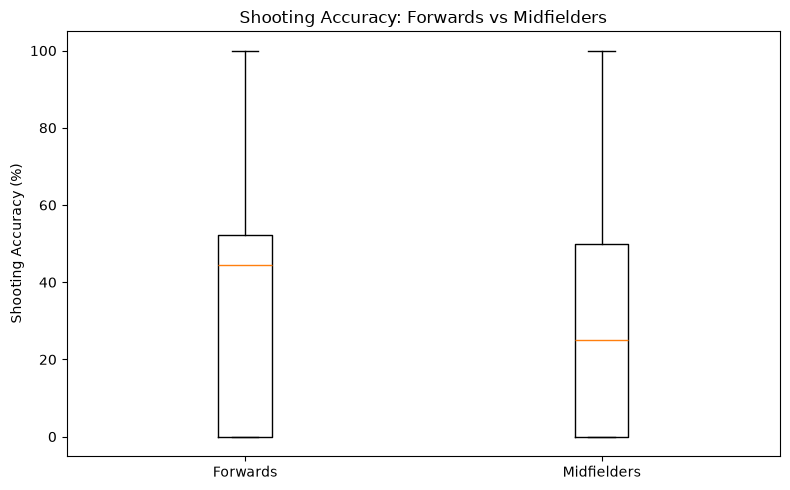

In [92]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        forward_accuracy,
        midfielder_accuracy
    ],
    tick_labels=[
        "Forwards",
        "Midfielders"
    ]
)

plt.ylabel(
    "Shooting Accuracy (%)"
)

plt.title(
    "Shooting Accuracy: "
    "Forwards vs Midfielders"
)

plt.tight_layout()

plt.show()

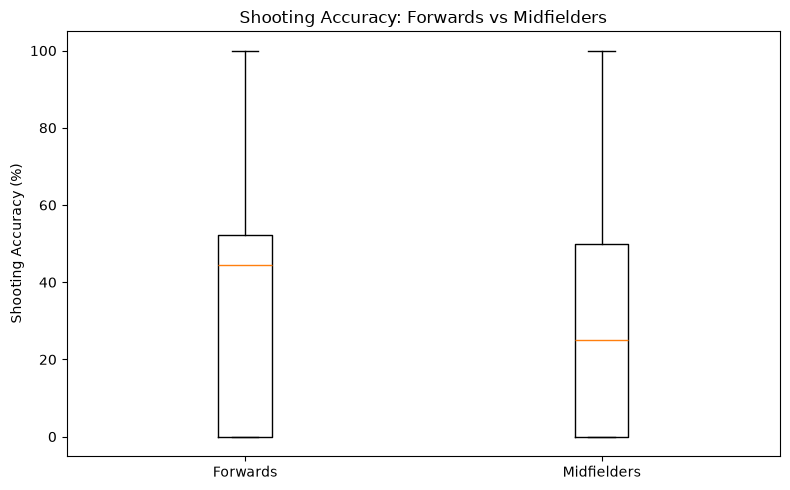

In [93]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        forward_accuracy,
        midfielder_accuracy
    ],
    tick_labels=[
        "Forwards",
        "Midfielders"
    ]
)

plt.ylabel(
    "Shooting Accuracy (%)"
)

plt.title(
    "Shooting Accuracy: "
    "Forwards vs Midfielders"
)

plt.tight_layout()

plt.savefig(
    "figures/shooting_accuracy_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

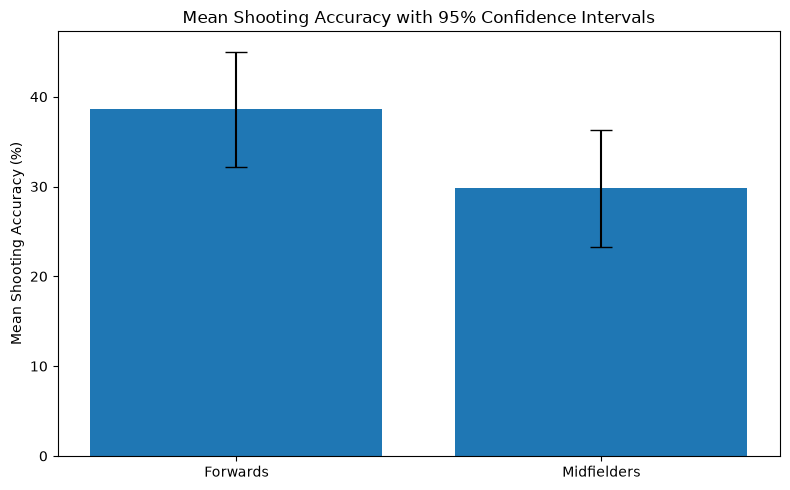

In [94]:
means = [
    fw_mean,
    mf_mean
]

errors = [
    fw_mean - fw_low,
    mf_mean - mf_low
]

plt.figure(figsize=(8, 5))

plt.bar(
    ["Forwards", "Midfielders"],
    means,
    yerr=errors,
    capsize=8
)

plt.ylabel(
    "Mean Shooting Accuracy (%)"
)

plt.title(
    "Mean Shooting Accuracy "
    "with 95% Confidence Intervals"
)

plt.tight_layout()

plt.savefig(
    "figures/shooting_accuracy_ci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()